# Первая лабораторная работа
## Основы PyTorch и обучение полносвязной нейронной сети
## Цель задания
В этой лабораторной работе необходимо пройти все этапы создания и обучения
нейронной сети на Python с использованием библиотеки PyTorch. Цель — научиться работать с тензорами, понять принцип автоматического
вычисления градиентов и создать простую полносвязную нейронную сеть
для классификации табличных данных.

In [1]:
import torch
import os, shutil
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from pathlib import Path
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import pandas as pd

## 2. Предобработка данных


In [2]:
os.makedirs("./data/splits/test/dummy", exist_ok=True)

for f in os.listdir("./data/splits/test"):
    if f.endswith(".png"):
        shutil.move(
            os.path.join("./data/splits/test", f),
            os.path.join("./data/splits/test/dummy", f)
        )

In [3]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = datasets.ImageFolder("./data/splits/train", transform=train_transform)
val_ds = datasets.ImageFolder("./data/splits/val", transform=test_transform)
test_ds = datasets.ImageFolder("./data/splits/test", transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

images, labels = next(iter(train_loader))
print(images.shape)

torch.Size([256, 3, 32, 32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.7764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.9372549].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.83137256].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.96862745].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.96862745].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].


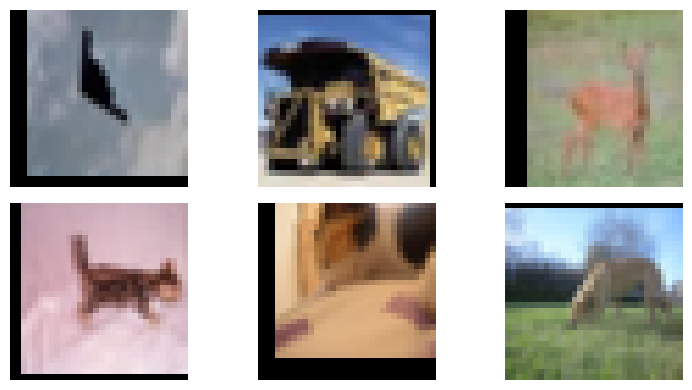

In [4]:
def denorm(img):
    img = img.clone()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return img


images, labels = next(iter(train_loader))

plt.figure(figsize=(8, 4))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(denorm(images[i]).permute(1, 2, 0))
    plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Построение и обучение свёрточной модели

In [5]:
device = torch.device("mps" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)


class MiniCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.drop2d = nn.Dropout2d(0.2)

        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.drop = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, n_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.drop2d(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool2(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x


model = MiniCNN(n_classes=len(train_ds.classes)).to(device)

opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss()

### 2.1 Обучение


In [6]:
EPOCHS = 15
PATIENCE = 5

best_val = -1.0
best_epoch = 0
train_losses = []
val_accs = []

print(torch.backends.mps.is_available())

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    n = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        opt.zero_grad()
        loss = crit(model(imgs), labels)
        loss.backward()
        opt.step()
        running_loss += loss.item() * imgs.size(0)
        n += imgs.size(0)
    train_loss = running_loss / n
    train_losses.append(train_loss)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            preds = out.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total
    val_accs.append(val_acc)

    print(f"Epoch {epoch:02d}  train_loss={train_loss:.4f}  val_acc={val_acc:.4f}")

    if val_acc > best_val:
        best_val = val_acc
        best_epoch = epoch
        torch.save(model.state_dict(), "best_model.pth")
        print("  -> saved best_model.pth")
    if epoch - best_epoch >= PATIENCE:
        print(f"Early stopping (no improvement for {PATIENCE} epochs).")
        break



True
Epoch 01  train_loss=1.8248  val_acc=0.4954
  -> saved best_model.pth
Epoch 02  train_loss=1.5514  val_acc=0.5522
  -> saved best_model.pth
Epoch 03  train_loss=1.4432  val_acc=0.6066
  -> saved best_model.pth
Epoch 04  train_loss=1.3691  val_acc=0.6172
  -> saved best_model.pth
Epoch 05  train_loss=1.3017  val_acc=0.6564
  -> saved best_model.pth
Epoch 06  train_loss=1.2521  val_acc=0.6698
  -> saved best_model.pth
Epoch 07  train_loss=1.2144  val_acc=0.6852
  -> saved best_model.pth
Epoch 08  train_loss=1.1798  val_acc=0.6768
Epoch 09  train_loss=1.1478  val_acc=0.7108
  -> saved best_model.pth
Epoch 10  train_loss=1.1300  val_acc=0.7176
  -> saved best_model.pth
Epoch 11  train_loss=1.1064  val_acc=0.7112
Epoch 12  train_loss=1.0913  val_acc=0.7272
  -> saved best_model.pth
Epoch 13  train_loss=1.0676  val_acc=0.7386
  -> saved best_model.pth
Epoch 14  train_loss=1.0458  val_acc=0.7394
  -> saved best_model.pth
Epoch 15  train_loss=1.0362  val_acc=0.7346


### 2.2 Тест

Saved submission.csv with 300000 rows


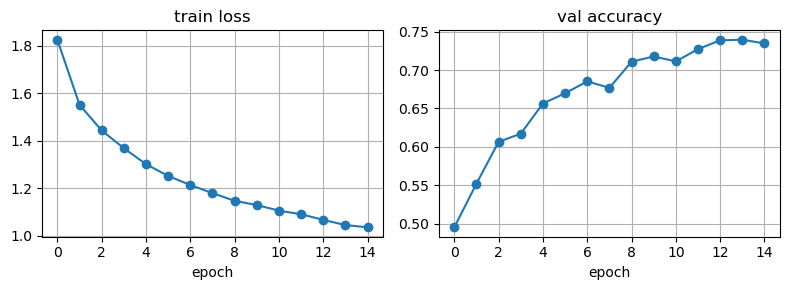

In [7]:
model.eval()
model.to(device)

names_all = [os.path.basename(p) for p, _ in test_ds.samples]

preds = []
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        out = model(imgs)
        batch_preds = out.argmax(dim=1).cpu().tolist()
        preds.extend(batch_preds)

CIFAR10_CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
labels_names = [CIFAR10_CLASS_NAMES[p] for p in preds]

ids = [int(Path(n).stem) for n in names_all]
df = pd.DataFrame({"id": ids, "label": labels_names})

df = df.sort_values("id").reset_index(drop=True)
df.to_csv("submission.csv", index=False)

print("Saved submission.csv with", len(df), "rows")

plt.figure(figsize=(14, 3))
plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o')
plt.title("train loss")
plt.xlabel("epoch")
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(val_accs, marker='o')
plt.title("val accuracy")
plt.xlabel("epoch")
plt.grid(True)
plt.tight_layout()
plt.savefig("curves.png", dpi=150)
plt.show()